# ⚙️ Étape 3 — Feature Engineering
## Projet : Analyse & Prédiction des flux de mobilité IDFM

---

### Pourquoi ce notebook ?

Les données brutes de MySQL ne sont pas directement utilisables par XGBoost.
Il faut les **transformer** en features (variables) que le modèle peut comprendre.

C'est souvent **plus impactant que le choix de l'algorithme** :
un XGBoost avec de mauvaises features sera battu par une régression linéaire
avec de bonnes features.

### Ce qu'on va créer dans ce notebook :

| Feature | Type | Pourquoi |
|---|---|---|
| `is_defini` | bool | Marquer les NON DEFINIS |
| `jour_semaine` | int (0-6) | Pattern hebdomadaire |
| `is_weekend` | bool | Chute de trafic le week-end |
| `mois` | int (7-9) | Effet saisonnier été/rentrée |
| `semaine_annee` | int | Numéro de semaine |
| `is_ferie` | bool | Comportement like dimanche |
| `is_vacances` | bool | Creux estival |
| `NB_VALD_lag1` | float | Trafic hier |
| `NB_VALD_lag7` | float | Trafic il y a 7 jours |
| `rolling_mean_7j` | float | Tendance récente |
| `rolling_std_7j` | float | Stabilité du trafic |
| `score_congestion` | float (0-1) | Niveau de saturation |
| `transporteur_encoded` | int | Code transporteur numérique |

### Fichiers utilisés
- **Entrée** : MySQL `idfm_mobility.validations` (468 226 lignes)
- **Entrée** : `data/external/calendrier_feries_fr.csv`
- **Sortie** : `data/processed/idfm_features.parquet`

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px
import plotly.graph_objects as go
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Ajouter le dossier src au path Python
# POURQUOI : pour pouvoir importer preprocessing.py
# qui est dans src/ et pas dans notebooks/
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))
import preprocessing as pp

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (14, 6)

print('OK Imports OK')

OK Imports OK


---
## ÉTAPE 3.0 — Chargement depuis MySQL

In [2]:
# ============================================================
# CHARGEMENT DEPUIS MYSQL
# ============================================================
# On charge les données brutes depuis MySQL
# C'est le même point de départ que l'EDA

engine = pp.get_engine()
df_raw = pp.load_from_mysql(engine)

print(f'Données brutes chargées : {len(df_raw):,} lignes')
print(f'Colonnes : {list(df_raw.columns)}')
display(df_raw.head(3))

2026-06-13 18:46:06,235 — INFO — Chargement depuis MySQL...
2026-06-13 18:46:23,334 — INFO — Chargé : 468,226 lignes


Données brutes chargées : 468,226 lignes
Colonnes : ['JOUR', 'CODE_STIF_TRNS', 'CODE_STIF_RES', 'CODE_STIF_ARRET', 'ID_ZDC', 'LIBELLE_ARRET', 'CATEGORIE_TITRE', 'NB_VALD']


,JOUR,CODE_STIF_TRNS,CODE_STIF_RES,CODE_STIF_ARRET,ID_ZDC,LIBELLE_ARRET,CATEGORIE_TITRE,NB_VALD
0,2025-07-18,800,803,424,59761,LARDY,Autres titres,1
1,2025-07-18,800,803,424,59761,LARDY,NON DEFINI,1
2,2025-07-18,800,803,444,70064,ARDOINES,Forfait Navigo,1586


---
## ÉTAPE 3.1 — Création de is_defini

### Pourquoi ?
On a vu dans l'EDA que **13.14% des lignes** sont NON DEFINI.
On les marque avec un booléen avant de faire quoi que ce soit.
- `True`  = titre connu (Navigo, Imagine R, etc.)
- `False` = titre non identifié → à exclure pour XGBoost

2026-06-13 18:46:58,007 — INFO — Création de is_defini...
2026-06-13 18:46:58,069 — INFO — is_defini créé — 61,508 lignes NON DEFINI (13.1%)


Répartition de is_defini :
is_defini
True     406718
False     61508
Name: count, dtype: int64

Proportion NON DEFINIS : 13.14%


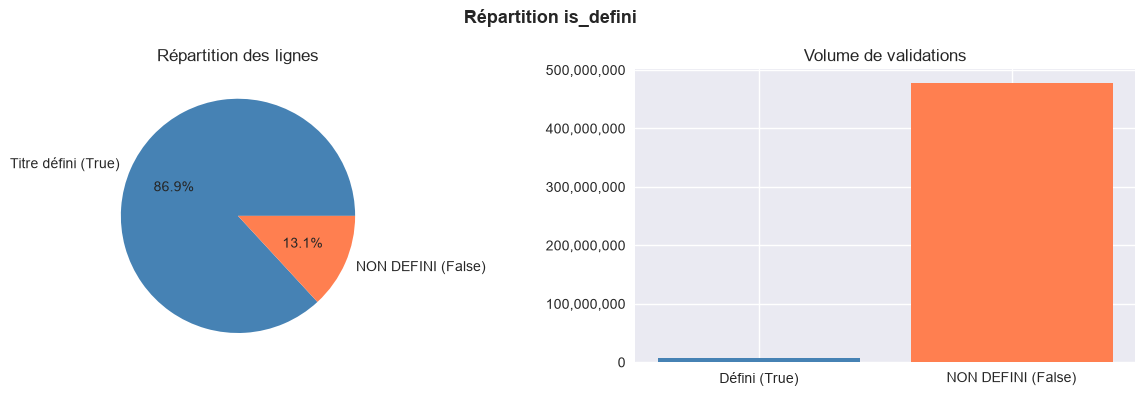


Décision : on garde les NON DEFINIS dans df_raw
mais on les EXCLUT lors de l agrégation pour XGBoost


In [3]:
# Créer is_defini
df_raw = pp.add_is_defini(df_raw)

# Vérification
print('Répartition de is_defini :')
vc = df_raw['is_defini'].value_counts()
print(vc)
print(f'\nProportion NON DEFINIS : {(~df_raw["is_defini"]).mean()*100:.2f}%')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Répartition is_defini', fontsize=13, fontweight='bold')

axes[0].pie(vc.values, labels=['Titre défini (True)', 'NON DEFINI (False)'],
            autopct='%1.1f%%', colors=['steelblue', 'coral'])
axes[0].set_title('Répartition des lignes')

vol = df_raw.groupby('is_defini')['NB_VALD'].sum()
axes[1].bar(['Défini (True)', 'NON DEFINI (False)'],
            vol.values, color=['steelblue', 'coral'])
axes[1].set_title('Volume de validations')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

print('\nDécision : on garde les NON DEFINIS dans df_raw')
print('mais on les EXCLUT lors de l agrégation pour XGBoost')

---
## ÉTAPE 3.2 — Agrégation par (LIBELLE_ARRET, JOUR)

### Pourquoi ?
Notre table brute a **plusieurs lignes par arrêt et par jour** (une par catégorie de titre).
XGBoost a besoin d'**une seule ligne** par (arrêt, jour) avec le trafic total.

On exclut les NON DEFINIS lors de cette agrégation.

In [4]:
# Agrégation
df = pp.aggregate_by_arret_jour(df_raw)

print(f'Avant agrégation : {len(df_raw):,} lignes')
print(f'Après agrégation : {len(df):,} lignes')
print(f'Réduction : {len(df_raw) - len(df):,} lignes supprimées (agrégées)')
print(f'\nLogique : 772 arrêts × 92 jours = {772*92:,} combinaisons possibles')
print(f'On obtient {len(df):,} car certains arrêts ne sont pas actifs tous les jours')

display(df.head(5))

# Vérification : distribution NB_VALD agrégé
fig = px.histogram(
    df, x='NB_VALD', nbins=80,
    title='Distribution de NB_VALD après agrégation par (arrêt, jour)',
    labels={'NB_VALD': 'Total validations par arrêt par jour'}
)
fig.update_layout(height=400)
fig.show()

print(f'\nNB_VALD agrégé — min: {df["NB_VALD"].min():,} | '
      f'médiane: {df["NB_VALD"].median():,.0f} | '
      f'max: {df["NB_VALD"].max():,}')

2026-06-13 18:47:14,948 — INFO — Agrégation par (LIBELLE_ARRET, JOUR)...
2026-06-13 18:47:15,584 — INFO — Agrégation terminée : 69,271 lignes (arrêt × jour)


Avant agrégation : 468,226 lignes
Après agrégation : 69,271 lignes
Réduction : 398,955 lignes supprimées (agrégées)

Logique : 772 arrêts × 92 jours = 71,024 combinaisons possibles
On obtient 69,271 car certains arrêts ne sont pas actifs tous les jours


,LIBELLE_ARRET,JOUR,NB_VALD,CODE_STIF_TRNS,CODE_STIF_RES,CODE_STIF_ARRET,ID_ZDC
0,ABBESSES,2025-07-01,6377,100,110,2,71432
1,ABBESSES,2025-07-02,6723,100,110,2,71432
2,ABBESSES,2025-07-03,7471,100,110,2,71432
3,ABBESSES,2025-07-04,7822,100,110,2,71432
4,ABBESSES,2025-07-05,8935,100,110,2,71432



NB_VALD agrégé — min: 1 | médiane: 3,927 | max: 289,995


---
## ÉTAPE 3.3 — Version pivot par catégorie de titre

### Pourquoi ?
Cette version donne une colonne par catégorie de titre.
Elle sera utile pour le **clustering** — un arrêt avec beaucoup d'Imagine R
a un profil différent d'un arrêt avec beaucoup de Forfaits courts.

In [5]:
# Créer le pivot
df_pivot = pp.create_pivot_by_titre(df_raw)

print('Version pivot — colonnes :')
print(list(df_pivot.columns))
print(f'\nShape : {df_pivot.shape}')
display(df_pivot.head(3))

print('\nCe pivot sera utilisé à l Etape 4 pour le clustering des arrêts')

2026-06-13 18:48:05,911 — INFO — Création du pivot par catégorie de titre...
2026-06-13 18:48:06,340 — INFO — Pivot créé : 69,693 lignes, 9 colonnes


Version pivot — colonnes :
['LIBELLE_ARRET', 'JOUR', 'amethyste', 'autres_titres', 'contrat_solidarité_transport', 'forfait_navigo', 'forfaits_courts', 'imagine_r', 'non_defini']

Shape : (69693, 9)


,LIBELLE_ARRET,JOUR,amethyste,autres_titres,contrat_solidarité_transport,forfait_navigo,forfaits_courts,imagine_r,non_defini
0,ABBESSES,2025-07-01,69,332,176,2203,2988,609,223
1,ABBESSES,2025-07-02,66,624,212,2571,2603,647,180
2,ABBESSES,2025-07-03,88,71,239,2894,3427,752,214



Ce pivot sera utilisé à l Etape 4 pour le clustering des arrêts


---
## ÉTAPE 3.4 — Variables temporelles

### Pourquoi ?
Le trafic de transport est fortement lié au calendrier.
Ces variables expliquent ~70% de la variance du trafic.

### Le fichier `calendrier_feries_fr.csv`
Il contient tous les jours fériés et les vacances scolaires
de la période juillet-septembre 2025.
Sans ce fichier, XGBoost ne saurait pas que le 14 juillet
ou les vacances d'été sont des jours spéciaux.

Contenu du calendrier :
Total : 65 jours
type
vacances    60
rentree      3
ferie        2
Name: count, dtype: int64

Jours fériés :


,date,type,description
13,2025-07-14,ferie,Fête Nationale
45,2025-08-15,ferie,Assomption


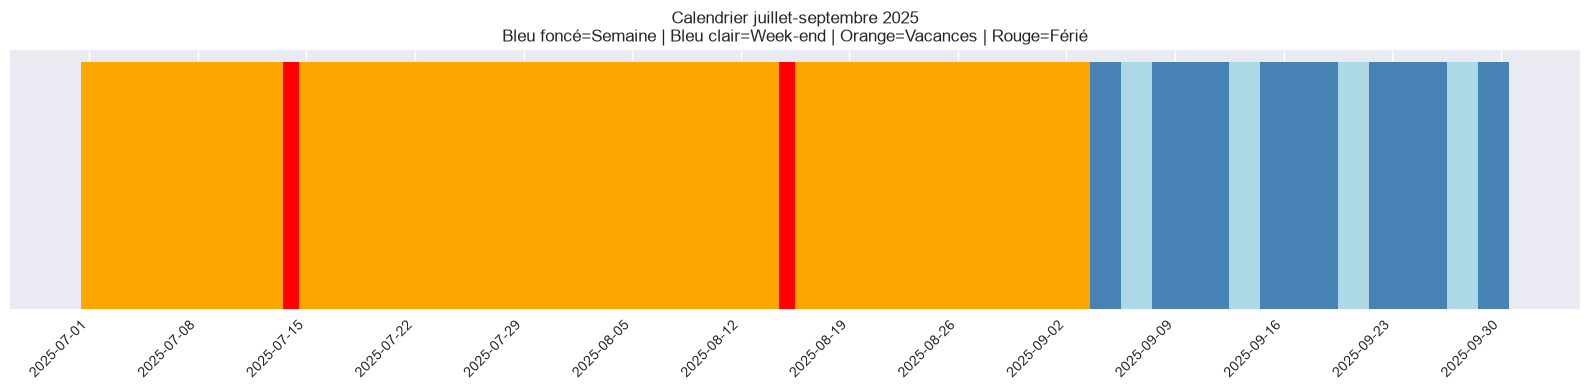

In [6]:
# Afficher le calendrier
cal = pd.read_csv('../data/external/calendrier_feries_fr.csv')
cal['date'] = pd.to_datetime(cal['date'])

print('Contenu du calendrier :')
print(f'Total : {len(cal)} jours')
print(cal['type'].value_counts())
print('\nJours fériés :')
display(cal[cal['type'] == 'ferie'])

# Visualiser le calendrier sur la période
fig, ax = plt.subplots(figsize=(16, 4))

# Tous les jours de la période
periode = pd.date_range('2025-07-01', '2025-09-30')
couleurs = []
for d in periode:
    if d in set(cal[cal['type'] == 'ferie']['date']):
        couleurs.append('red')
    elif d in set(cal[cal['type'].isin(['vacances', 'rentree'])]['date']):
        couleurs.append('orange')
    elif d.dayofweek >= 5:
        couleurs.append('lightblue')
    else:
        couleurs.append('steelblue')

ax.bar(range(len(periode)), [1]*len(periode), color=couleurs, width=1)
ax.set_xticks(range(0, len(periode), 7))
ax.set_xticklabels([str(periode[i].date()) for i in range(0, len(periode), 7)],
                    rotation=45, ha='right')
ax.set_yticks([])
ax.set_title('Calendrier juillet-septembre 2025\n'
             'Bleu foncé=Semaine | Bleu clair=Week-end | Orange=Vacances | Rouge=Férié',
             fontsize=12)
plt.tight_layout()
plt.show()

2026-06-13 18:48:32,460 — INFO — Ajout des variables temporelles...
2026-06-13 18:48:32,540 — INFO — Calendrier chargé — 2 jours fériés, 63 jours de vacances
2026-06-13 18:48:32,542 — INFO — Variables temporelles créées


Variables temporelles créées :


,JOUR,jour_semaine,is_weekend,mois,semaine_annee,is_ferie,is_vacances
0,2025-07-01,1,False,7,27,False,True
1,2025-07-02,2,False,7,27,False,True
2,2025-07-03,3,False,7,27,False,True
3,2025-07-04,4,False,7,27,False,True
4,2025-07-05,5,True,7,27,False,True
5,2025-07-06,6,True,7,27,False,True
6,2025-07-07,0,False,7,28,False,True
7,2025-07-08,1,False,7,28,False,True
8,2025-07-09,2,False,7,28,False,True
9,2025-07-10,3,False,7,28,False,True



Répartition :
  Jours de semaine : 49,783
  Week-ends        : 19,488
  Jours fériés     : 1,497
  Jours de vacances: 47,080


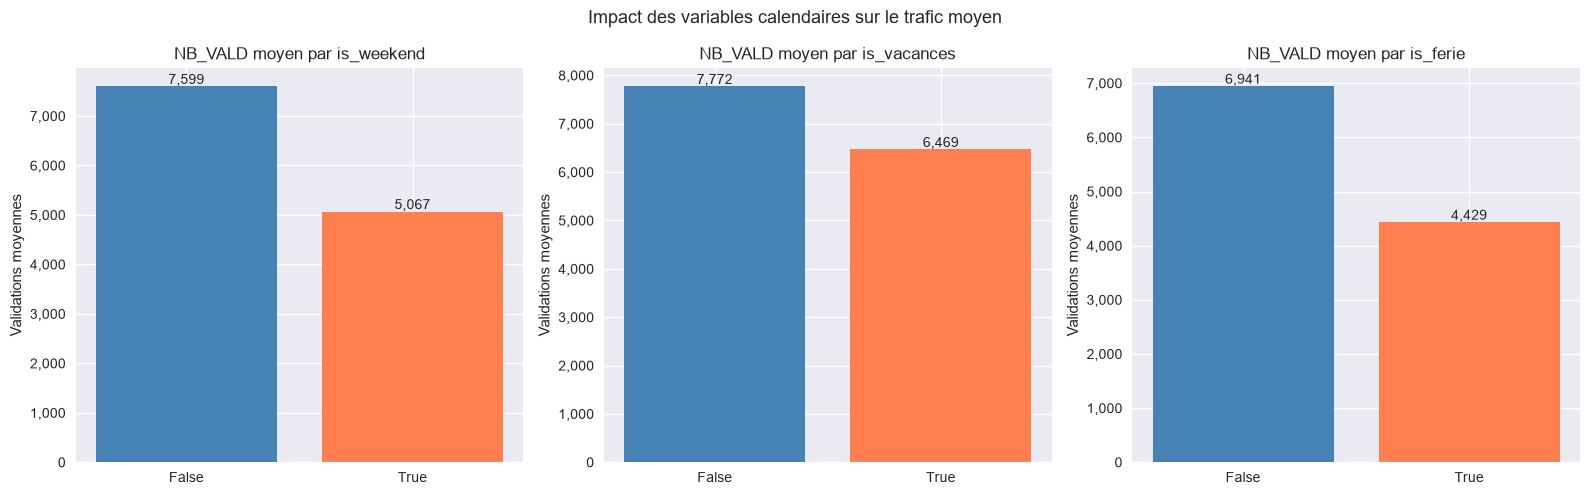


Lecture : si la barre True est significativement différente de False
=> la variable est utile pour XGBoost


In [7]:
# Ajouter les variables temporelles
df = pp.add_temporal_features(df, calendrier_path='../data/external/calendrier_feries_fr.csv')

print('Variables temporelles créées :')
cols_tempo = ['JOUR', 'jour_semaine', 'is_weekend', 'mois',
              'semaine_annee', 'is_ferie', 'is_vacances']
display(df[cols_tempo].head(10))

print('\nRépartition :')
print(f'  Jours de semaine : {(~df["is_weekend"]).sum():,}')
print(f'  Week-ends        : {df["is_weekend"].sum():,}')
print(f'  Jours fériés     : {df["is_ferie"].sum():,}')
print(f'  Jours de vacances: {df["is_vacances"].sum():,}')

# Vérification visuelle : trafic moyen par is_vacances et is_weekend
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, titre in zip(
    axes,
    ['is_weekend', 'is_vacances', 'is_ferie'],
    ['is_weekend', 'is_vacances', 'is_ferie']
):
    moy = df.groupby(col)['NB_VALD'].mean()
    ax.bar(['False', 'True'], moy.values,
           color=['steelblue', 'coral'])
    ax.set_title(f'NB_VALD moyen par {titre}')
    ax.set_ylabel('Validations moyennes')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
    for i, v in enumerate(moy.values):
        ax.text(i, v + 50, f'{v:,.0f}', ha='center', fontsize=10)

plt.suptitle('Impact des variables calendaires sur le trafic moyen', fontsize=13)
plt.tight_layout()
plt.show()

print('\nLecture : si la barre True est significativement différente de False')
print('=> la variable est utile pour XGBoost')

---
## ÉTAPE 3.5 — Variables de lag

### Pourquoi les lags ?
Un lag c'est simplement **la valeur passée** d'une variable.

Pour prédire le trafic de demain à CHATELET :
- **lag1** = trafic de CHATELET hier → signal immédiat
- **lag7** = trafic de CHATELET il y a 7 jours → même jour la semaine dernière
- **rolling_mean_7j** = moyenne des 7 derniers jours → tendance récente

lag7 est la feature la plus prédictive car le trafic est cyclique sur 7 jours.
Un lundi ressemble toujours au lundi de la semaine précédente.

In [8]:
# Créer les lags
df = pp.add_lag_features(df)

print('Variables de lag créées :')
cols_lag = ['LIBELLE_ARRET', 'JOUR', 'NB_VALD',
            'NB_VALD_lag1', 'NB_VALD_lag7', 'rolling_mean_7j', 'rolling_std_7j']
display(df[cols_lag].head(15))

# Vérification des NULL
print('\nNULL après traitement :')
print(df[['NB_VALD_lag1', 'NB_VALD_lag7',
          'rolling_mean_7j', 'rolling_std_7j']].isnull().sum())

# Visualisation : lag7 vs NB_VALD pour un arrêt exemple
arret_exemple = 'CHATELET'
df_arret = df[df['LIBELLE_ARRET'] == arret_exemple].sort_values('JOUR')

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_arret['JOUR'], y=df_arret['NB_VALD'],
    mode='lines', name='NB_VALD (réel)',
    line=dict(color='steelblue', width=2)
))
fig.add_trace(go.Scatter(
    x=df_arret['JOUR'], y=df_arret['NB_VALD_lag7'],
    mode='lines', name='NB_VALD_lag7 (il y a 7 jours)',
    line=dict(color='red', width=2, dash='dash')
))
fig.add_trace(go.Scatter(
    x=df_arret['JOUR'], y=df_arret['rolling_mean_7j'],
    mode='lines', name='rolling_mean_7j',
    line=dict(color='green', width=2, dash='dot')
))
fig.update_layout(
    title=f'NB_VALD vs lag7 vs rolling_mean — {arret_exemple}',
    xaxis_title='Date', yaxis_title='Validations',
    height=450, hovermode='x unified'
)
fig.show()

print(f'\nObservation : lag7 (rouge) suit de près NB_VALD (bleu) décalé de 7 jours')
print('C est la preuve que le trafic est cyclique sur 7 jours')
print('=> lag7 sera la feature la plus importante dans XGBoost')

2026-06-13 18:48:47,876 — INFO — Création des variables de lag...
2026-06-13 18:48:48,916 — INFO — Lags créés — NULL restants : 2


Variables de lag créées :


,LIBELLE_ARRET,JOUR,NB_VALD,NB_VALD_lag1,NB_VALD_lag7,rolling_mean_7j,rolling_std_7j
0,ABBESSES,2025-07-01,6377,6484.0,6476.0,6377.000000,0.000000
1,ABBESSES,2025-07-02,6723,6377.0,6476.0,6550.000000,244.658946
2,ABBESSES,2025-07-03,7471,6723.0,6476.0,6857.000000,559.174391
3,ABBESSES,2025-07-04,7822,7471.0,6476.0,7098.250000,664.271719
4,ABBESSES,2025-07-05,8935,7822.0,6476.0,7465.600000,1002.832389
5,ABBESSES,2025-07-06,6476,8935.0,6476.0,7300.666667,983.746038
6,ABBESSES,2025-07-07,7262,6476.0,6476.0,7295.142857,898.152071
7,ABBESSES,2025-07-08,8274,7262.0,6377.0,7566.142857,860.344007
8,ABBESSES,2025-07-09,3857,8274.0,6723.0,7156.714286,1648.968335
9,ABBESSES,2025-07-10,6484,3857.0,7471.0,7015.714286,1659.778169



NULL après traitement :
NB_VALD_lag1       0
NB_VALD_lag7       2
rolling_mean_7j    0
rolling_std_7j     0
dtype: int64



Observation : lag7 (rouge) suit de près NB_VALD (bleu) décalé de 7 jours
C est la preuve que le trafic est cyclique sur 7 jours
=> lag7 sera la feature la plus importante dans XGBoost


In [9]:
# Corrélation entre les lags et NB_VALD
# POURQUOI : mesurer précisément à quel point chaque lag
# est corrélé avec la valeur cible (NB_VALD)
# Une corrélation proche de 1.0 = feature très prédictive

cols_corr = ['NB_VALD', 'NB_VALD_lag1', 'NB_VALD_lag7',
             'rolling_mean_7j', 'rolling_std_7j']
corr = df[cols_corr].corr()['NB_VALD'].drop('NB_VALD').sort_values(ascending=False)

fig = px.bar(
    x=corr.index, y=corr.values,
    title='Corrélation entre les lags et NB_VALD (valeur cible)',
    labels={'x': 'Feature', 'y': 'Corrélation avec NB_VALD'},
    color=corr.values,
    color_continuous_scale='RdYlGn',
    text=corr.round(3).values
)
fig.add_hline(y=0.7, line_dash='dash', line_color='green',
              annotation_text='Seuil bonne corrélation (0.7)')
fig.update_traces(textposition='outside')
fig.update_layout(height=450)
fig.show()

print('Interprétation :')
print('  > 0.9 = corrélation très forte = feature très utile')
print('  0.7 - 0.9 = corrélation forte = feature utile')
print('  < 0.5 = corrélation faible = feature moins utile')

Interprétation :
  > 0.9 = corrélation très forte = feature très utile
  0.7 - 0.9 = corrélation forte = feature utile
  < 0.5 = corrélation faible = feature moins utile


---
## ÉTAPE 3.6 — Score de congestion

### Pourquoi ?
Le score = NB_VALD / max historique de l'arrêt.
Il permet de **comparer des arrêts de tailles très différentes**.
Saint-Lazare à 0.5 = 50% de son record.
Ablon à 0.5 = 50% de son record.
Les deux arrêts sont comparables malgré des volumes très différents.

2026-06-13 18:49:14,395 — INFO — Calcul du score de congestion...
2026-06-13 18:49:14,414 — INFO — Score de congestion calculé — min: 0.000, max: 1.000


Score de congestion créé :
count    69271.000000
mean         0.582636
std          0.238211
min          0.000000
25%          0.406400
50%          0.591600
75%          0.775500
max          1.000000
Name: score_congestion, dtype: float64


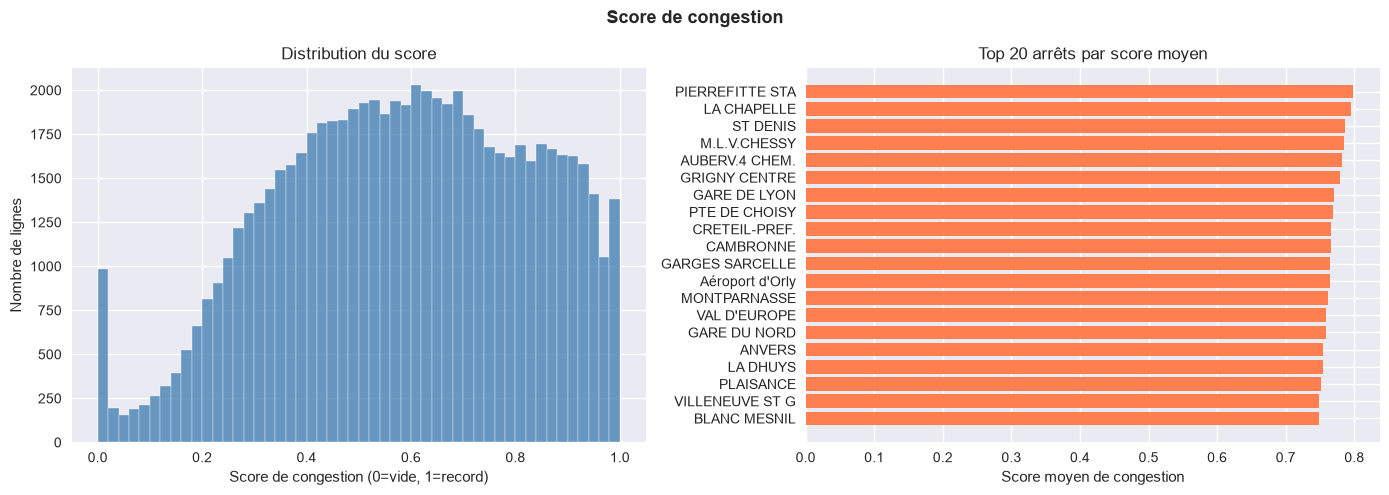

In [10]:
# Calculer le score de congestion
df = pp.add_congestion_score(df)

print('Score de congestion créé :')
print(df['score_congestion'].describe())

# Distribution du score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Score de congestion', fontsize=13, fontweight='bold')

# Histogramme
axes[0].hist(df['score_congestion'], bins=50, color='steelblue',
             edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Score de congestion (0=vide, 1=record)')
axes[0].set_ylabel('Nombre de lignes')
axes[0].set_title('Distribution du score')

# Score moyen par arrêt (Top 20)
score_moy = (df.groupby('LIBELLE_ARRET')['score_congestion']
               .mean().nlargest(20).reset_index())
axes[1].barh(score_moy['LIBELLE_ARRET'], score_moy['score_congestion'],
             color='coral')
axes[1].set_xlabel('Score moyen de congestion')
axes[1].set_title('Top 20 arrêts par score moyen')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Exemple : score de CHATELET dans le temps
df_chatelet = df[df['LIBELLE_ARRET'] == 'CHATELET'].sort_values('JOUR')

fig = px.line(
    df_chatelet, x='JOUR', y='score_congestion',
    title='Score de congestion de CHATELET sur 92 jours',
    labels={'score_congestion': 'Score (0=vide, 1=record)', 'JOUR': 'Date'}
)
fig.add_hline(y=0.5, line_dash='dash', line_color='orange',
              annotation_text='50% du maximum')
fig.update_layout(height=400)
fig.show()

---
## ÉTAPE 3.7 — Encodage du transporteur

### Pourquoi encoder ?
XGBoost ne peut pas travailler avec des codes texte.
`CODE_STIF_TRNS` contient des codes comme 100, 800, 810.
On les transforme en entiers ordonnés 0, 1, 2...

In [11]:
# Encoder le transporteur
df = pp.encode_transporteur(df)

print('Encodage du transporteur :')
display(df[['CODE_STIF_TRNS', 'transporteur_encoded']]
        .drop_duplicates()
        .sort_values('transporteur_encoded'))

print('\nRépartition des transporteurs :')
print(df['CODE_STIF_TRNS'].value_counts())

2026-06-13 18:49:22,547 — INFO — Encodage du transporteur...
2026-06-13 18:49:22,616 — INFO — Transporteurs encodés : {'100': 0, '760': 1, '761': 2, '762': 3, '800': 4, '810': 5}


Encodage du transporteur :


,CODE_STIF_TRNS,transporteur_encoded
0,100,0
3340,760,1
68903,761,2
61754,762,3
92,800,4
184,810,5



Répartition des transporteurs :
CODE_STIF_TRNS
800    33060
100    28149
810     7786
760       92
762       92
761       92
Name: count, dtype: int64


---
## RÉCAPITULATIF — Toutes les features créées

In [12]:
# Vue d'ensemble du DataFrame final
print('=' * 60)
print('RÉCAPITULATIF DU DATASET ENRICHI')
print('=' * 60)
print(f'Shape : {df.shape}')
print(f'\nColonnes et types :')
print(df.dtypes)

print(f'\nValeurs manquantes :')
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else 'Aucune valeur manquante')

print(f'\nAperçu :')
display(df.head(5))

# Séparer features d'entrée et variable cible
features_xgboost = [
    'jour_semaine', 'is_weekend', 'mois', 'semaine_annee',
    'is_ferie', 'is_vacances',
    'NB_VALD_lag1', 'NB_VALD_lag7',
    'rolling_mean_7j', 'rolling_std_7j',
    'score_congestion', 'transporteur_encoded'
]
cible = 'NB_VALD'

print(f'\nFeatures pour XGBoost ({len(features_xgboost)}) :')
for f in features_xgboost:
    print(f'  - {f}')
print(f'\nVariable cible : {cible}')

RÉCAPITULATIF DU DATASET ENRICHI
Shape : (69271, 20)

Colonnes et types :
LIBELLE_ARRET                   object
JOUR                    datetime64[ns]
NB_VALD                          int64
CODE_STIF_TRNS                   int64
CODE_STIF_RES                   object
CODE_STIF_ARRET                 object
ID_ZDC                           int64
jour_semaine                     int32
is_weekend                        bool
mois                             int32
semaine_annee                    int64
annee                            int32
is_ferie                          bool
is_vacances                       bool
NB_VALD_lag1                   float64
NB_VALD_lag7                   float64
rolling_mean_7j                float64
rolling_std_7j                 float64
score_congestion               float64
transporteur_encoded             int64
dtype: object

Valeurs manquantes :
NB_VALD_lag7    2
dtype: int64

Aperçu :


,LIBELLE_ARRET,JOUR,NB_VALD,CODE_STIF_TRNS,CODE_STIF_RES,CODE_STIF_ARRET,ID_ZDC,jour_semaine,is_weekend,mois,semaine_annee,annee,is_ferie,is_vacances,NB_VALD_lag1,NB_VALD_lag7,rolling_mean_7j,rolling_std_7j,score_congestion,transporteur_encoded
0,ABBESSES,2025-07-01,6377,100,110,2,71432,1,False,7,27,2025,False,True,6484.0,6476.0,6377.00,0.000000,0.7018,0
1,ABBESSES,2025-07-02,6723,100,110,2,71432,2,False,7,27,2025,False,True,6377.0,6476.0,6550.00,244.658946,0.7398,0
2,ABBESSES,2025-07-03,7471,100,110,2,71432,3,False,7,27,2025,False,True,6723.0,6476.0,6857.00,559.174391,0.8222,0
3,ABBESSES,2025-07-04,7822,100,110,2,71432,4,False,7,27,2025,False,True,7471.0,6476.0,7098.25,664.271719,0.8608,0
4,ABBESSES,2025-07-05,8935,100,110,2,71432,5,True,7,27,2025,False,True,7822.0,6476.0,7465.60,1002.832389,0.9833,0



Features pour XGBoost (12) :
  - jour_semaine
  - is_weekend
  - mois
  - semaine_annee
  - is_ferie
  - is_vacances
  - NB_VALD_lag1
  - NB_VALD_lag7
  - rolling_mean_7j
  - rolling_std_7j
  - score_congestion
  - transporteur_encoded

Variable cible : NB_VALD


---
## EXPORT FINAL — Sauvegarde en Parquet

In [13]:
# ============================================================
# EXPORT EN PARQUET
# ============================================================
# POURQUOI PARQUET ?
# 1. Compression automatique — beaucoup plus léger qu'un CSV
# 2. Lecture rapide — optimisé pour la lecture analytique
# 3. Types conservés — bool reste bool, datetime reste datetime
#    (un CSV stocke tout comme texte = re-conversion à chaque lecture)
# 4. Standard industrie — utilisé par Spark, AWS, Databricks

output_path = '../data/processed/idfm_features.parquet'
pp.export_to_parquet(df, output_path=output_path)

# Vérification : relire le Parquet et vérifier
df_check = pd.read_parquet(output_path)
print(f'\nVérification Parquet :')
print(f'  Lignes  : {len(df_check):,}')
print(f'  Colonnes: {len(df_check.columns)}')
print(f'  Types conservés :')
print(df_check.dtypes)
print(f'\nOK Parquet sauvegardé et vérifié avec succès !')
print(f'Chemin : {output_path}')
print(f'\nOn passe à l Etape 4 — Modèles ML !')

2026-06-13 18:58:38,992 — INFO — Parquet sauvegardé : ../data/processed/idfm_features.parquet
2026-06-13 18:58:38,995 — INFO — Taille : 1.8 MB | Lignes : 69,271 | Colonnes : 20
2026-06-13 18:58:38,999 — INFO — Colonnes : ['LIBELLE_ARRET', 'JOUR', 'NB_VALD', 'CODE_STIF_TRNS', 'CODE_STIF_RES', 'CODE_STIF_ARRET', 'ID_ZDC', 'jour_semaine', 'is_weekend', 'mois', 'semaine_annee', 'annee', 'is_ferie', 'is_vacances', 'NB_VALD_lag1', 'NB_VALD_lag7', 'rolling_mean_7j', 'rolling_std_7j', 'score_congestion', 'transporteur_encoded']



Vérification Parquet :
  Lignes  : 69,271
  Colonnes: 20
  Types conservés :
LIBELLE_ARRET                   object
JOUR                    datetime64[ns]
NB_VALD                          int64
CODE_STIF_TRNS                   int64
CODE_STIF_RES                   object
CODE_STIF_ARRET                 object
ID_ZDC                           int64
jour_semaine                     int32
is_weekend                        bool
mois                             int32
semaine_annee                    int64
annee                            int32
is_ferie                          bool
is_vacances                       bool
NB_VALD_lag1                   float64
NB_VALD_lag7                   float64
rolling_mean_7j                float64
rolling_std_7j                 float64
score_congestion               float64
transporteur_encoded             int64
dtype: object

OK Parquet sauvegardé et vérifié avec succès !
Chemin : ../data/processed/idfm_features.parquet

On passe à l Etape 4 — Modèles